## MMTHE01 - Masters Thesis

### E3. Thesis - Apply and Evaluate different XAI methods - Case Study with the ANN Model

* Applying XAI on a Deep Learning AI model (ANN Model)

#### Importing the libraries

In [1]:
### import general libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import re

from sklearn.preprocessing import LabelEncoder

In [2]:
### Import libraries to save models
import pickle
from tensorflow.keras.models import Model, load_model

In [3]:
# Fix the random seed so that the same sample is always chosen
np.random.seed(1)

In [4]:
## Check your current working directory
cwd = os.getcwd()

# Build the full path
full_path = r"C:\Users\eaber\Documents\Master Thesis Final\Analysis"

# Check if it exists before changing
if os.path.exists(full_path):
    os.chdir(full_path)
    print("Changed directory to:", full_path)
else:
    print("Folder does not exist:", full_path)

Folder does not exist: C:\Users\eaber\Documents\Master Thesis Final\Analysis


#### Load Dataset

In [5]:
with open("saved_data/Oversampled_datasets_folder.pkl","rb") as f:
    X_train_np, y_train_np, X_test_np, y_test_np, X_train_scaled_np, X_test_scaled_np = pickle.load(f)

In [6]:
### Import the pickle saved dataset
with open("saved_data/selected_features_final.pkl","rb") as f:
    selected_features_final = pickle.load(f)

In [7]:
if 'default_status' in selected_features_final:
    selected_features_final.remove('default_status')
    
feature_names = [re.sub(r"[ <>+]", "_", c).replace(" ", "_") for c in selected_features_final]

In [8]:
# Convert to dataframe
#X_train = pd.DataFrame(X_train_np, columns=feature_names).apply(pd.to_numeric)
#X_test = pd.DataFrame(X_test_np, columns=feature_names).apply(pd.to_numeric)
X_train_scaled_full = pd.DataFrame(X_train_scaled_np, columns=feature_names).apply(pd.to_numeric)
X_test_scaled_full = pd.DataFrame(X_test_scaled_np, columns=feature_names).apply(pd.to_numeric)

y_train_full = pd.DataFrame(y_train_np, columns=['default_status'])
y_test_full = pd.DataFrame(y_test_np, columns=['default_status'])

#### Obtaining samples for the evaluation (top X train, top y test)

In [9]:
X_train_scaled = X_train_scaled_full #.head(200)
X_test_scaled = X_test_scaled_full #.head(40)

In [10]:
y_train = y_train_full #.head(200)
y_test = y_test_full #.head(40)

#### Loading the models

In [11]:
# load ANN model
model = load_model("saved_models/ann_model_Oversampled.keras")

In [12]:
#X_test_batch = X_test_scaled.values[:2048]  # for testing, full run will use all values
#y_test_batch = y_test.values[:2048] 

In [13]:
import tensorflow as tf

In [14]:
## Define index for local tests
idx = 1

#### Function to combine scores of One Hot Encoded (OHE) features and show original feature names

In [15]:
original_features = ['title', 'sub_grade', 'issue_year', 'verification_status', 'loan_amnt', 'home_ownership', 'mo_sin_old_il_acct', 'dti', 
                     'acc_open_past_24mths', 'total_il_high_credit_limit', 'issue_month', 'mths_since_recent_inq', 'total_bc_limit', 'purpose',
                     'tot_hi_cred_lim', 'emp_title', 'num_tl_op_past_12m', 'num_bc_tl', 'avg_cur_bal', 'annual_inc', 'num_actv_bc_tl',
                     'percent_bc_gt_75', 'pub_rec_bankruptcies', 'term_in_months', 'mo_sin_rcnt_tl', 'pct_tl_nvr_dlq', 'mo_sin_old_rev_tl_op', 
                     'num_actv_rev_tl', 'num_tl_30dpd', 'earliest_cr_line_year', 'mths_since_recent_bc', 'revol_bal', 'revol_util', 'total_rev_hi_lim', 
                     'inq_last_6mths', 'bc_util', 'num_accts_ever_120_pd', 'earliest_cr_line_month', 'mort_acc', 'bc_open_to_buy', 'num_tl_90g_dpd_24m', 
                     'total_bal_ex_mort', 'num_bc_sats', 'num_il_tl', 'delinq_2yrs', 'num_rev_accts', 'num_op_rev_tl', 'pub_rec', 'initial_list_status',
                     'tax_liens', 'open_acc', 'delinq_amnt', 'total_acc', 'emp_length', 'collections_12_mths_ex_med', 'mo_sin_rcnt_rev_tl_op']

In [16]:
# Initialize a list to hold aggregated rows
agg_rows = []

In [17]:
def aggregate_ohe_importances_vectorized(df, feature_col='feature', importance_col='importance'):
    """
    Aggregate one-hot encoded features into their original categorical variable in a vectorized way.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing feature importances.
    ohe_features : list of str
        List of base feature names that were one-hot encoded.
    feature_col : str
        Column name for feature names.
    importance_col : str
        Column name for signed feature importance values.

    Returns:
    --------
    agg_df : pd.DataFrame
        Aggregated DataFrame with 'feature', 'importance', 'abs_importance', sorted by abs_importance descending.
    """
    
    df = df.copy()
    
    # 1. Replace original columns with base feature name
    for base_col in original_features:
        if base_col == 'title':
            df.loc[df[feature_col].str.startswith(base_col), feature_col] = base_col
        elif base_col == 'pub_rec':
            pattern = r'\b' + re.escape(base_col) + r'\b'
            df[feature_col] = df[feature_col].str.replace(pattern, base_col, regex=True)
        else:
            df[feature_col] = df[feature_col].apply(lambda x: base_col if base_col in x else x)
    
    # 2. Group by feature and sum importance values
    agg_df = df.groupby(feature_col, as_index=False)[importance_col].sum()
    
    # 3. Create absolute importance column
    agg_df['abs_'+importance_col] = agg_df[importance_col].abs()
    
    # 4. Sort by absolute importance descending
    agg_df = agg_df.sort_values(by='abs_'+importance_col, ascending=False).reset_index(drop=True)
    
    return agg_df

In [18]:
# Increase global font sizes
plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.titlesize": 16,      # title
    "axes.labelsize": 14,      # x/y labels
    "xtick.labelsize": 14,     # x tick labels
    "ytick.labelsize": 14      # y tick labels
})

### 5.3 Applying XAI methods to the ANN Model

#### 5.3.9 Applying Layer-wise Relevance Propagation (LRP) to the ANN Model
* E3E. Thesis - Test different XAI methods with the ANN Model (LRP)

In [19]:
try:
    import innvestigate
    import innvestigate.utils as iutils
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


In [20]:
try:
    # Strip the final activation for analysis
    analyze_model = iutils.keras.graph.model_wo_softmax(model)
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


In [21]:
try:
    # Create the analyzer: options include "lrp.epsilon", "lrp.z", "lrp.z_plus", "lrp.alpha_1_beta_0"
    # ε helps stabilise divisions (good default for tabular)
    analyzer = innvestigate.create_analyzer(
        "lrp.epsilon",            # or "lrp.z", "lrp.z_plus", "lrp.alpha_1_beta_0"
        analyze_model,
        epsilon=1e-6
    )
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


In [22]:
start_time = time.time()

In [23]:
# Optionally, restrict to a subset for speed
try:
    X_batch = X_test_scaled.values[:2048]  # use all X_test.values for full run
    R = analyzer.analyze(X_batch)   # shape: (n_samples, n_features)
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


In [24]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"LRP on ANN (Explanation Time): {explanation_time:.2f} seconds")

LRP on ANN (Explanation Time): 0.34 seconds


##### Local implementation of LRP

In [25]:
try:
    # Local (per-sample) relevance DataFrame
    lrp_df = pd.DataFrame(R, columns=feature_names)
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


In [26]:
try:
    # Visualize one one test row
    i = 0
    row_relevance = lrp_df.iloc[i].sort_values(key=np.abs, ascending=False)
    print(row_relevance.head(15))
    
    # Quick bar plot
    n = 15
    plt.figure(figsize=(8, 5))
    plt.barh(row_relevance.index[:n][::-1], row_relevance.values[:n][::-1])
    plt.title(f"LRP (ε-rule) — Per-feature relevance for test sample #{i}")
    plt.xlabel("Relevance (signed)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


##### Global implementation of LRP

In [27]:
try:
    # Global importance: mean absolute relevance across samples
    global_importance = (
        lrp_df.abs().mean(axis=0).sort_values(ascending=False)
    )
    topk = 20
    print(global_importance.head(topk))
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


In [28]:
try:
    top = global_importance.head(topk)[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top.index, top.values)
    plt.title("LRP (ε-rule) — Top Features by Mean |Relevance|")
    plt.xlabel("Mean absolute relevance")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Technique not usable.")
    print(f"Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.\
    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.")

Technique not usable.
Innvestigate 1.0.9 requires keras==2.2.4, but you have keras 3.11.3 which is incompatible.    Keras=2.2.4 requires tensor=2.6 which is no longer in distribution.


#### 5.3.10 Applying Integrated Gradients (IG) to the ANN Model
* E3E. Thesis - Test different XAI methods with the ANN Model (IG)

In [29]:
# Integrated Gradients function
@tf.function
def interpolate_inputs(baseline, input, alphas):
    alphas_x = alphas[:, tf.newaxis] * (input - baseline) + baseline
    return alphas_x

def integrated_gradients(model, input, X_train=None, steps=50):
    if X_train is None:
        # fallback to zeros if training data not provided
        baseline = tf.zeros_like(input)  # all zeros baseline
    else:
        baseline = tf.convert_to_tensor([X_train.mean().values], dtype=tf.float32)
    
    # Generate alphas from 0 to 1
    alphas = tf.linspace(0.0, 1.0, steps)
    
    # Interpolated inputs
    interpolated_inputs = interpolate_inputs(baseline, input, alphas)
    
    # Gradient function
    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        preds = model(interpolated_inputs)
    grads = tape.gradient(preds, interpolated_inputs)
    
    # Average gradients and scale
    avg_grads = tf.reduce_mean(grads, axis=0)
    integrated_grad = (input - baseline) * avg_grads
    return integrated_grad.numpy()

In [30]:
baseline_df = pd.DataFrame([X_train_scaled.mean(axis=0)], columns=X_train_scaled.columns)

##### Local implementation of IG

In [31]:
start_time = time.time()

In [32]:
X_test_scaled.head()

,acc_open_past_24mths,annual_inc,avg_cur_bal,bc_open_to_buy,bc_util,collections_12_mths_ex_med,delinq_2yrs,delinq_amnt,dti,earliest_cr_line_month_Apr,...,title,tot_hi_cred_lim,total_acc,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,verification_status_Not_Verified,verification_status_Source_Verified,verification_status_Verified
0,-1.463339,-0.343983,-0.706375,-0.527756,0.087212,-0.118429,-0.357884,-0.017951,-1.258509,-0.287676,...,1.600503,-0.920415,-1.184783,-0.954903,-0.735588,-0.994118,-0.704208,1.510576,-0.807128,-0.655931
1,0.404425,-0.316488,0.374022,-0.654693,1.203167,-0.118429,-0.357884,-0.017951,-0.324102,-0.287676,...,-0.741852,0.282401,-0.438984,-0.810385,-0.804072,-0.287210,-0.587099,1.510576,-0.807128,-0.655931
2,-0.840751,-0.014043,-0.262383,-0.368140,-0.513686,-0.118429,-0.357884,-0.017951,0.001490,-0.287676,...,-0.330436,-0.503259,-0.853317,0.415858,-0.612315,0.641374,-0.650158,-0.661999,1.238961,-0.655931
3,-0.218163,1.017018,0.705151,2.282226,-0.595952,-0.118429,-0.357884,-0.017951,0.231365,-0.287676,...,2.747480,1.933947,1.218347,0.303058,2.661245,0.547045,1.451799,-0.661999,1.238961,-0.655931
4,-0.057172,-0.572191,0.037484,0.056545,-0.048416,-0.118429,-0.357884,-0.017951,0.105051,-0.287676,...,0.381657,0.041162,-0.273251,0.009249,0.050919,0.010029,0.040671,1.510576,-0.807128,-0.655931


In [33]:
# Get the first row as a 2D array (batch of 1)
idx=1
x_sample = tf.convert_to_tensor(X_test_scaled.iloc[[idx]], dtype=tf.float32)

print(x_sample.shape)  # (1, n_features)

(1, 109)


In [34]:
local_ig = integrated_gradients(model, x_sample, X_train=baseline_df, steps=50)[0]

In [35]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"IG Local on ANN (Explanation Time): {explanation_time:.2f} seconds")

IG Local on ANN (Explanation Time): 0.62 seconds


In [36]:
local_df_ohe = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "attribution": local_ig
})

In [37]:
len(local_df_ohe)

109

In [38]:
local_df = aggregate_ohe_importances_vectorized(local_df_ohe, feature_col='feature', importance_col='attribution')
local_df.to_csv('intermediate_output/XAI all features ranked/ANN_Local_Integrated_Gradient_allR.csv',index=False)

In [39]:
local_df10 = local_df.head(10)

In [40]:
local_df10.to_csv('intermediate_output/XAI top 10 features/ANN_Local_Integrated_Gradient_top10.csv',index=False)

In [41]:
local_df10.head(3)

,feature,attribution,abs_attribution
0,sub_grade,-0.129252,0.129252
1,issue_year,-0.118313,0.118313
2,verification_status,-0.046002,0.046002


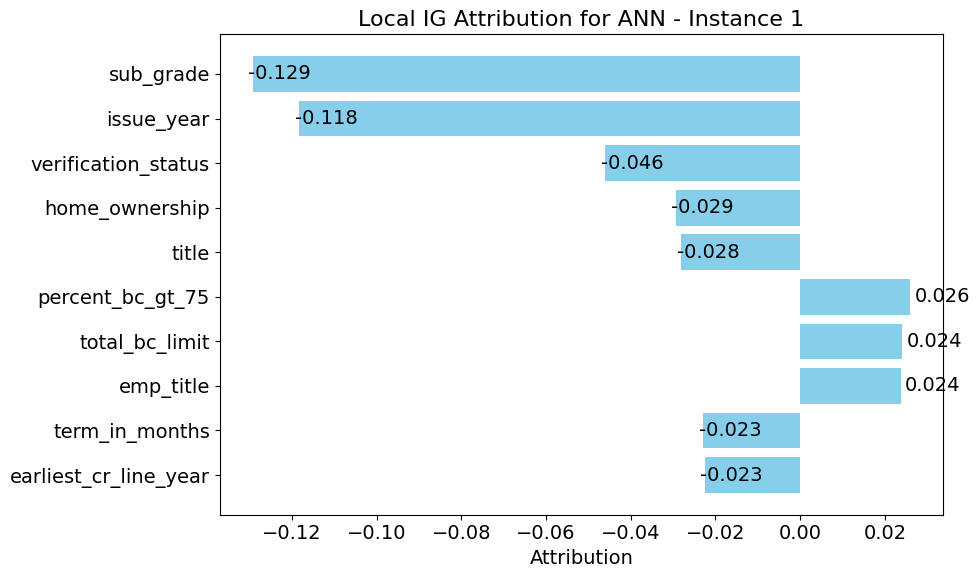

In [42]:
# Plot local explanation
plt.figure(figsize=(10,6))
bars = plt.barh(local_df10["feature"], local_df10["attribution"], color='skyblue')
plt.title("Local IG Attribution for ANN - Instance {}".format(idx))
plt.xlabel("Attribution")
plt.gca().invert_yaxis()  # largest on top

# Add value labels
for i, bar in enumerate(bars):
    value = local_df10["attribution"][::1].iloc[i]
    plt.text(value + 0.001 if value > 0 else value - 0.001,
             bar.get_y() + bar.get_height()/2,
             f"{value:.3f}", va='center')

plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/ANN_Local_Integrated_Gradient_top10', dpi=300)
plt.show()

##### Global implementation of IG

In [43]:
len(X_test_scaled)

45214

In [44]:
ig_attributions = []
n_samples = len(X_test_scaled)

In [45]:
start_time = time.time()

In [46]:
for i in range(n_samples):
    x = tf.convert_to_tensor([X_test_scaled.iloc[i].values], dtype=tf.float32)
    ig_attr = integrated_gradients(model, x, X_train=baseline_df, steps=50)
    ig_attributions.append(ig_attr[0])

In [47]:
ig_attributions = np.array(ig_attributions)

In [48]:
# Aggregate absolute values
global_importance = np.mean(ig_attributions, axis=0)
global_importance_abs = np.abs(np.mean(ig_attributions, axis=0))

In [49]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"IG Global on ANN (Explanation Time): {explanation_time:.2f} seconds")

IG Global on ANN (Explanation Time): 666.81 seconds


In [50]:
global_df_ohe = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "importance": global_importance,
    "importance_abs": global_importance_abs
})

In [51]:
len(global_df_ohe)

109

In [52]:
global_df = aggregate_ohe_importances_vectorized(global_df_ohe, feature_col='feature', importance_col='importance')
global_df.to_csv('intermediate_output/XAI all features ranked/ANN_Global_Integrated_Gradient_allR.csv',index=False)

In [53]:
global_df10 = global_df.head(10)

In [54]:
global_df10.to_csv('intermediate_output/XAI top 10 features/ANN_Global_Integrated_Gradient_top10.csv',index=False)

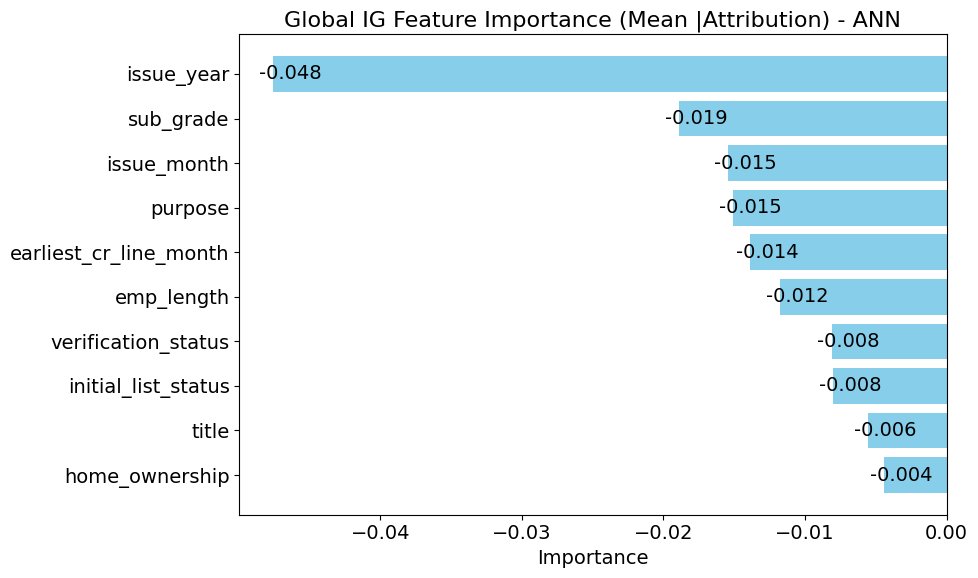

In [55]:
# Plot global explanation
plt.figure(figsize=(10,6))
bars = plt.barh(global_df10["feature"], global_df10["importance"], color='skyblue')
plt.title("Global IG Feature Importance (Mean |Attribution) - ANN")
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # largest on top

# Add value labels
for i, bar in enumerate(bars):
    value = global_df10["importance"][::1].iloc[i]
    plt.text(value + 0.001 if value > 0 else value - 0.001,
             bar.get_y() + bar.get_height()/2,
             f"{value:.3f}", va='center')

plt.tight_layout()
plt.savefig('intermediate_output/XAI top 10 features graphs/ANN_Global_Integrated_Gradient_top10', dpi=300)
plt.show()

#### 5.3.11 Applying DeepLIFT to the ANN Model
* E3E. Thesis - Test different XAI methods with the ANN Model (DeepLIFT)

In [56]:
try:
    import deeplift
    from deeplift.layers import NonlinearMxtsMode
    from deeplift.conversion import kerasapi_conversion as kc
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

In [57]:
try:
    # Convert Keras Sequential model to DeepLIFT model
    deeplift_model = kc.convert_model_from_keras(model, nonlinear_mxts_mode=NonlinearMxtsMode.RevealCancel)
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


In [58]:
try:
    # Define reference (baseline) input, e.g., all zeros
    reference = np.zeros((1, X_train_scaled.shape[1]))
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

In [59]:
try:
    # Choose target layer (output layer for binary classification)
    target_layer_idx = -1
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

In [60]:
try:
    # Define scoring function for DeepLIFT (target neuron 0, the output)
    deeplift_func = deeplift_model.get_target_contribs_func(find_scores_layer_idx=target_layer_idx)
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


##### Local implementation of DeepLIFT

In [61]:
start_time = time.time()

In [62]:
try:
    # Compute DeepLIFT contributions for one instance (local explanation)
    idx = 0
    x_sample = X_test_scaled[idx:idx+1]
    contribs = deeplift_func(task_idx=0, input_data_list=[x_sample], input_references_list=[reference])[0]
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


In [63]:
end_time = time.time()
explanation_time = end_time - start_time
print(f"DeepLIFT on ANN (Explanation Time): {explanation_time:.2f} seconds")

DeepLIFT on ANN (Explanation Time): 0.01 seconds


In [64]:
try:
    # Convert to DataFrame
    local_dl = pd.DataFrame({
        "feature": X.columns,
        "contribution": contribs[0]
    }).sort_values(by="contribution", key=abs, ascending=False)
    
    print("\nLocal DeepLIFT contributions (instance 0):")
    print(local_dl.head(10))
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


In [65]:
try:
    # Plot top 10
    plt.figure(figsize=(10,6))
    plt.barh(local_dl["feature"].head(10)[::-1], local_dl["contribution"].head(10)[::-1])
    plt.title("Local DeepLIFT Contributions (Instance 0)")
    plt.show()
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


<Figure size 1000x600 with 0 Axes>

##### Global implementation of DeepLIFT

In [66]:
# Global explanation (mean absolute contributions over multiple instances)
try:
    n_samples = 500
    dl_all = []
    for i in range(n_samples):
        x = X_test_scaled[i:i+1]
        dl_attr = deeplift_func(task_idx=0, input_data_list=[x], input_references_list=[reference])[0]
        dl_all.append(dl_attr[0])
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


In [67]:
try:
    dl_all = np.array(dl_all)
    global_dl = pd.DataFrame({
    "feature": X.columns,
    "importance": np.mean(np.abs(dl_all), axis=0)
    }).sort_values(by="importance", ascending=False)
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


In [68]:
try:
    plt.figure(figsize=(10,6))
    plt.barh(global_dl["feature"].head(15)[::-1], global_dl["importance"].head(15)[::-1])
    plt.title("Global DeepLIFT (Mean |Contribution|)")
    plt.show()
except Exception as e:
    print(f"Technique not usable.")
    print(f"DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x\
    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.")

Technique not usable.
DeepLIFT has not been updated in a while. deeplift was originally designed for TensorFlow 1.x / Keras 2.x    With modern TF 2.x / Keras 2.18+, most deeplift functions (like convert_model_from_keras) no longer exist or fail to import.


<Figure size 1000x600 with 0 Axes>